In [2]:
# Cell 1: Install Kaggle and Download Dataset
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud

!unzip -o creditcardfraud.zip


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


Libraries imported successfully!
Dataset Shape: (284807, 31)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     28

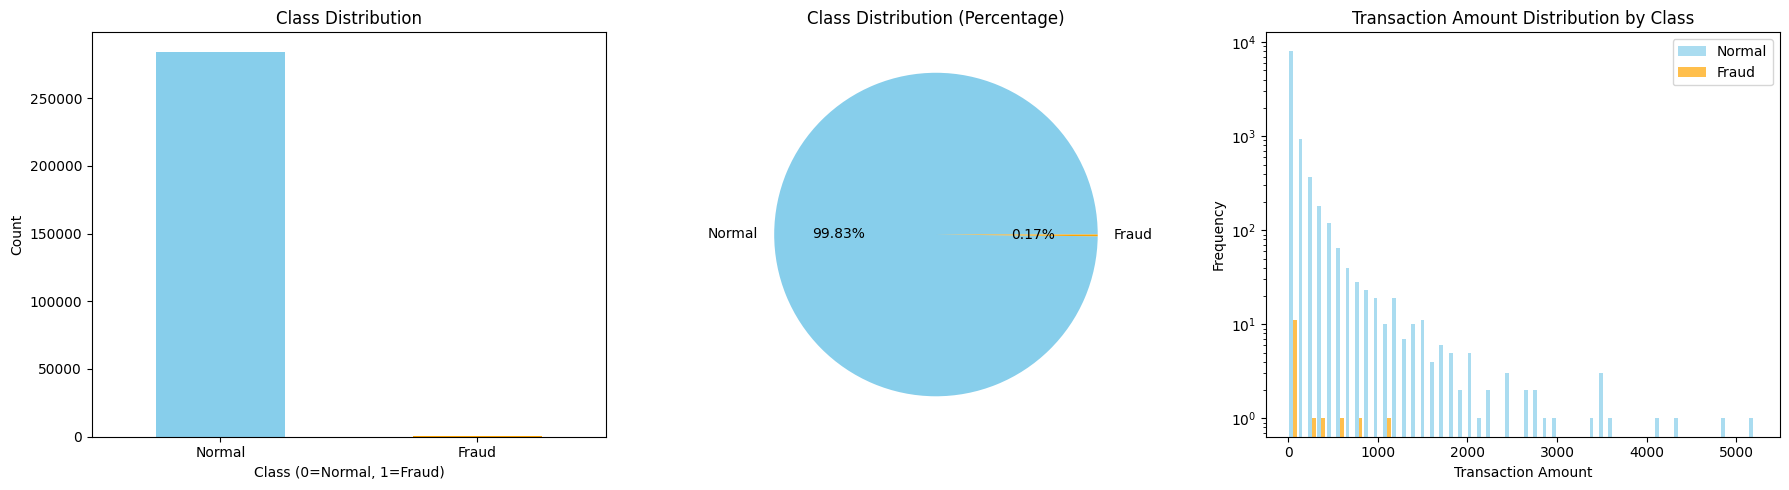

Data split completed:
Training set: X=(227845, 29), y=227845
Test set: X=(56962, 29), y=56962

Training set distribution:
  Normal: 227451 (99.83%)
  Fraud: 394 (0.17%)

Test set distribution:
  Normal: 56864 (99.83%)
  Fraud: 98 (0.17%)
Training Basic Logistic Regression...
Training Class-Balanced Logistic Regression...
Making predictions...
Models trained successfully!
                 MODEL PERFORMANCE COMPARISON

=== Basic Logistic Regression - Training Set ===
Accuracy: 0.9992 (99.92%)
Precision: 0.8834
Recall: 0.6345
F1-Score: 0.7386
AUC-ROC: 0.9819

=== Basic Logistic Regression - Test Set ===
Accuracy: 0.9992 (99.92%)
Precision: 0.8289
Recall: 0.6429
F1-Score: 0.7241
AUC-ROC: 0.9578

=== Balanced Logistic Regression - Training Set ===
Accuracy: 0.9756 (97.56%)
Precision: 0.0620
Recall: 0.9289
F1-Score: 0.1162
AUC-ROC: 0.9893

=== Balanced Logistic Regression - Test Set ===
Accuracy: 0.9745 (97.45%)
Precision: 0.0586
Recall: 0.9184
F1-Score: 0.1101
AUC-ROC: 0.9714

=== ERROR RAT

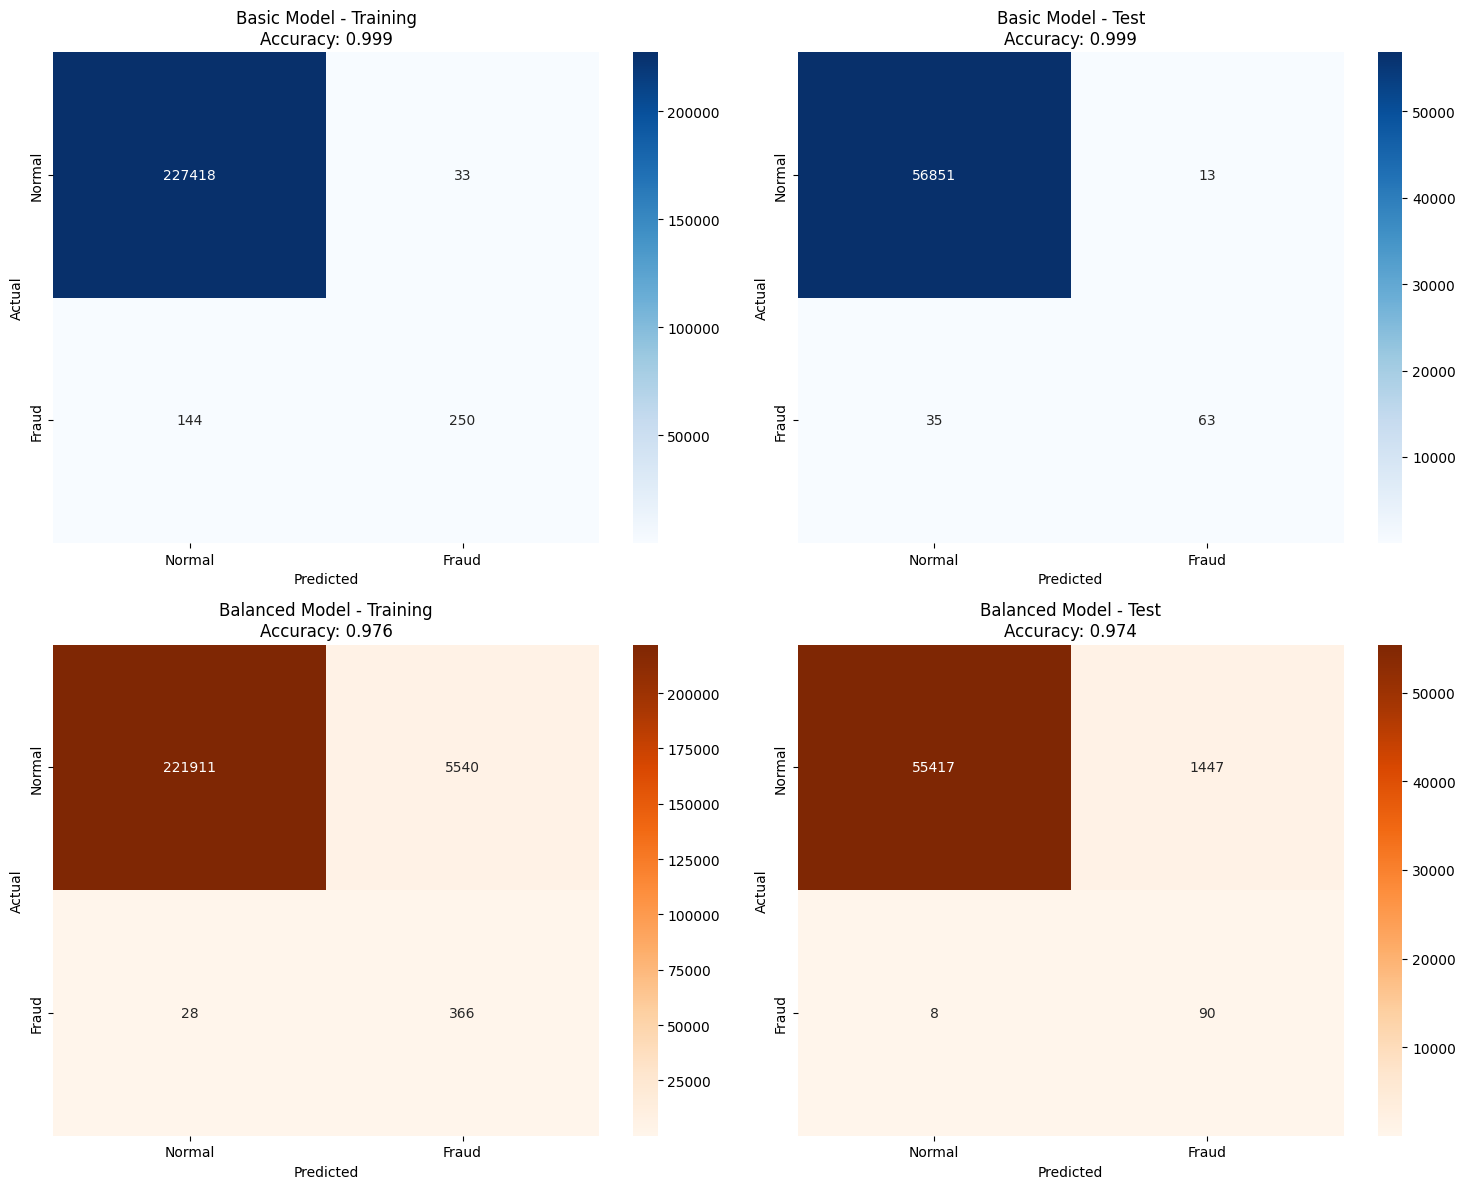

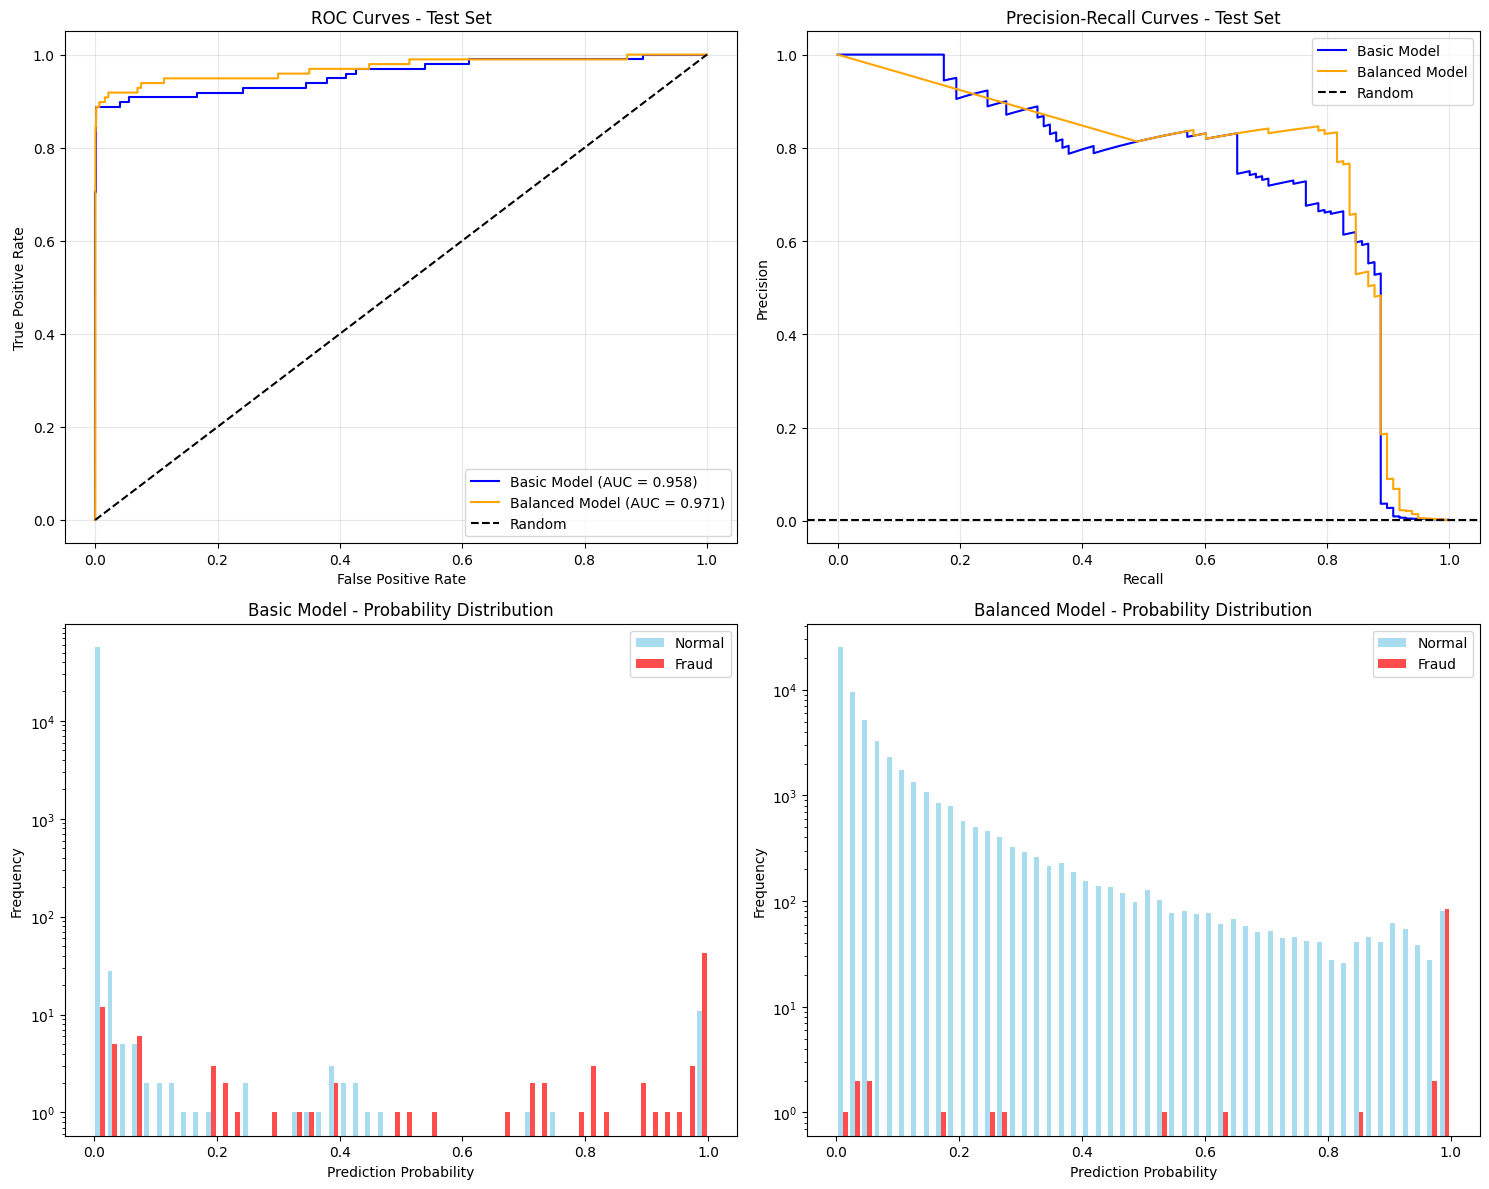

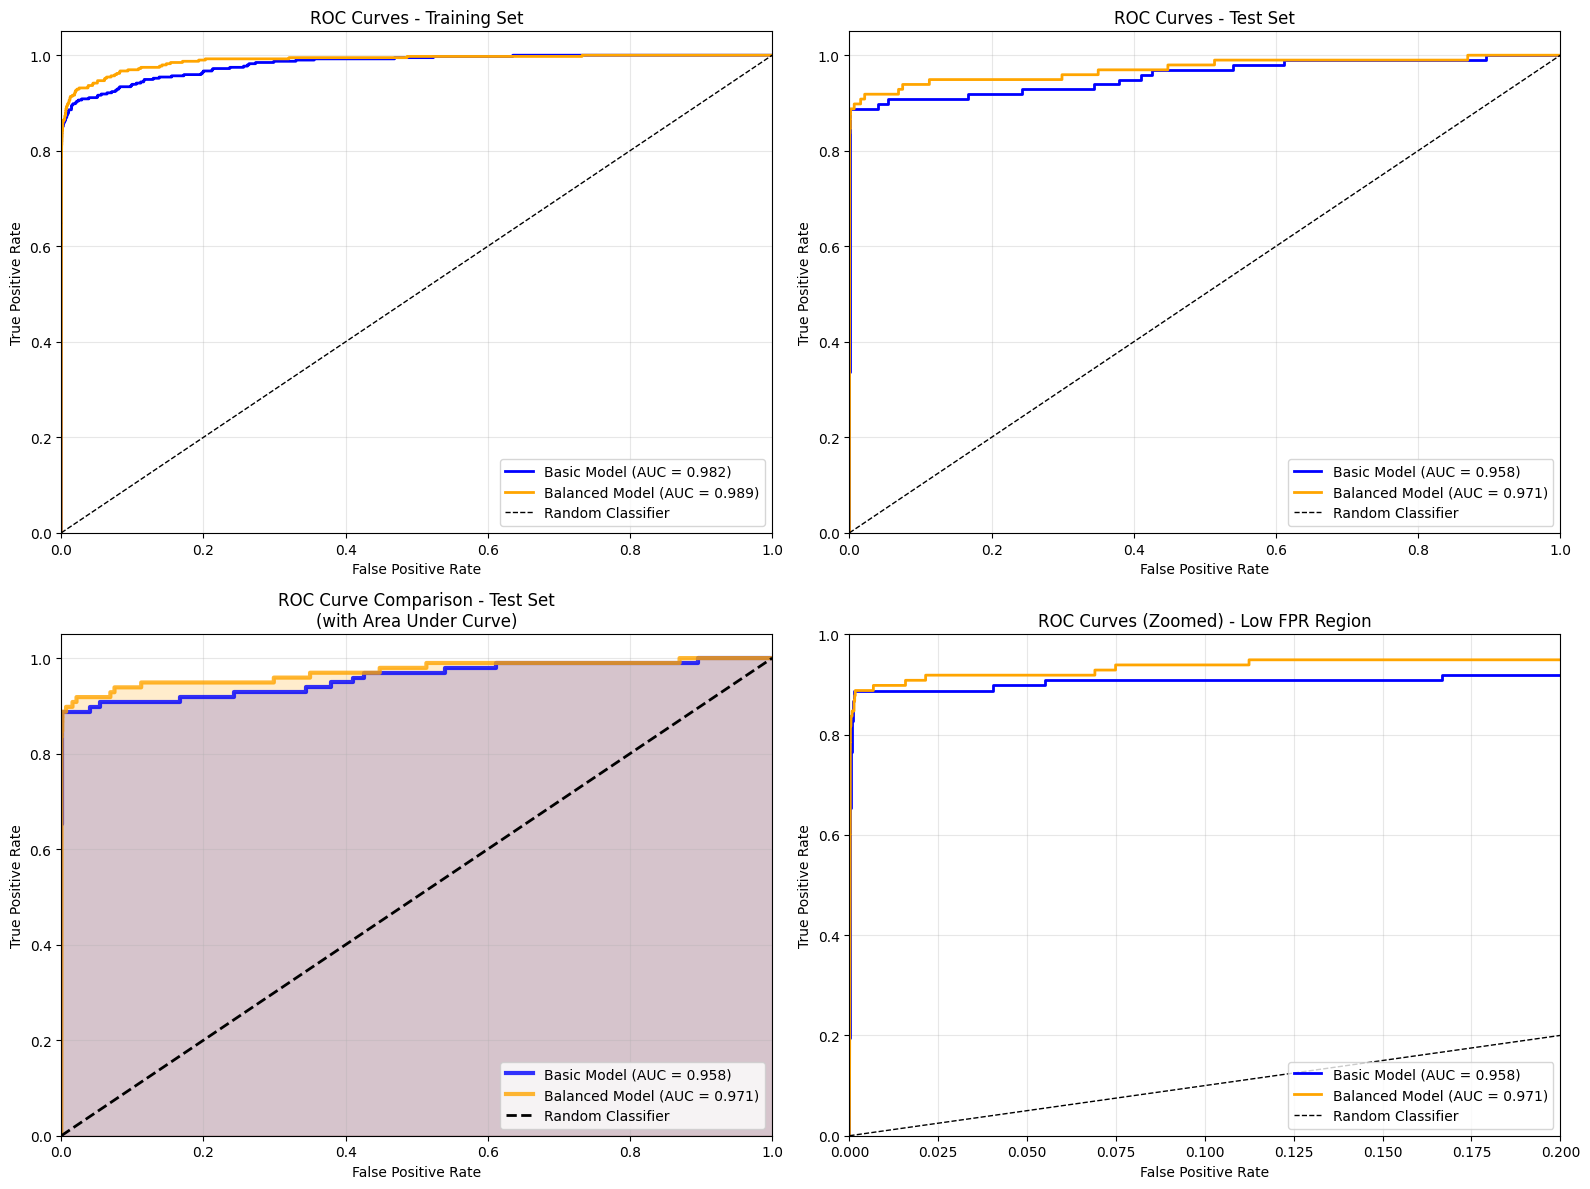

                ROC CURVE ANALYSIS
Training Set AUC Scores:
  Basic Model:    0.9819
  Balanced Model: 0.9893

Test Set AUC Scores:
  Basic Model:    0.9578
  Balanced Model: 0.9714

Optimal Thresholds (Youden's J statistic):
  Basic Model:    0.0193
  Balanced Model: 0.5397

At Optimal Thresholds:
  Basic Model - TPR: 0.888, FPR: 0.001
  Balanced Model - TPR: 0.918, FPR: 0.021

ROC Curve Insights:
✅ Balanced Model has better AUC (0.971 vs 0.958)
📊 AUC Interpretation:
   0.5 = Random classifier
   0.5-0.7 = Poor performance
   0.7-0.8 = Fair performance
   0.8-0.9 = Good performance
   0.9-1.0 = Excellent performance
=== PREDICTION CONFIDENCE ANALYSIS ===
Basic Model:
  Training - Mean confidence: 0.999
  Training - Std confidence: 0.008
  Test - Mean confidence: 0.999
  Test - Std confidence: 0.009

Balanced Model:
  Training - Mean confidence: 0.936
  Training - Std confidence: 0.094
  Test - Mean confidence: 0.936
  Test - Std confidence: 0.095


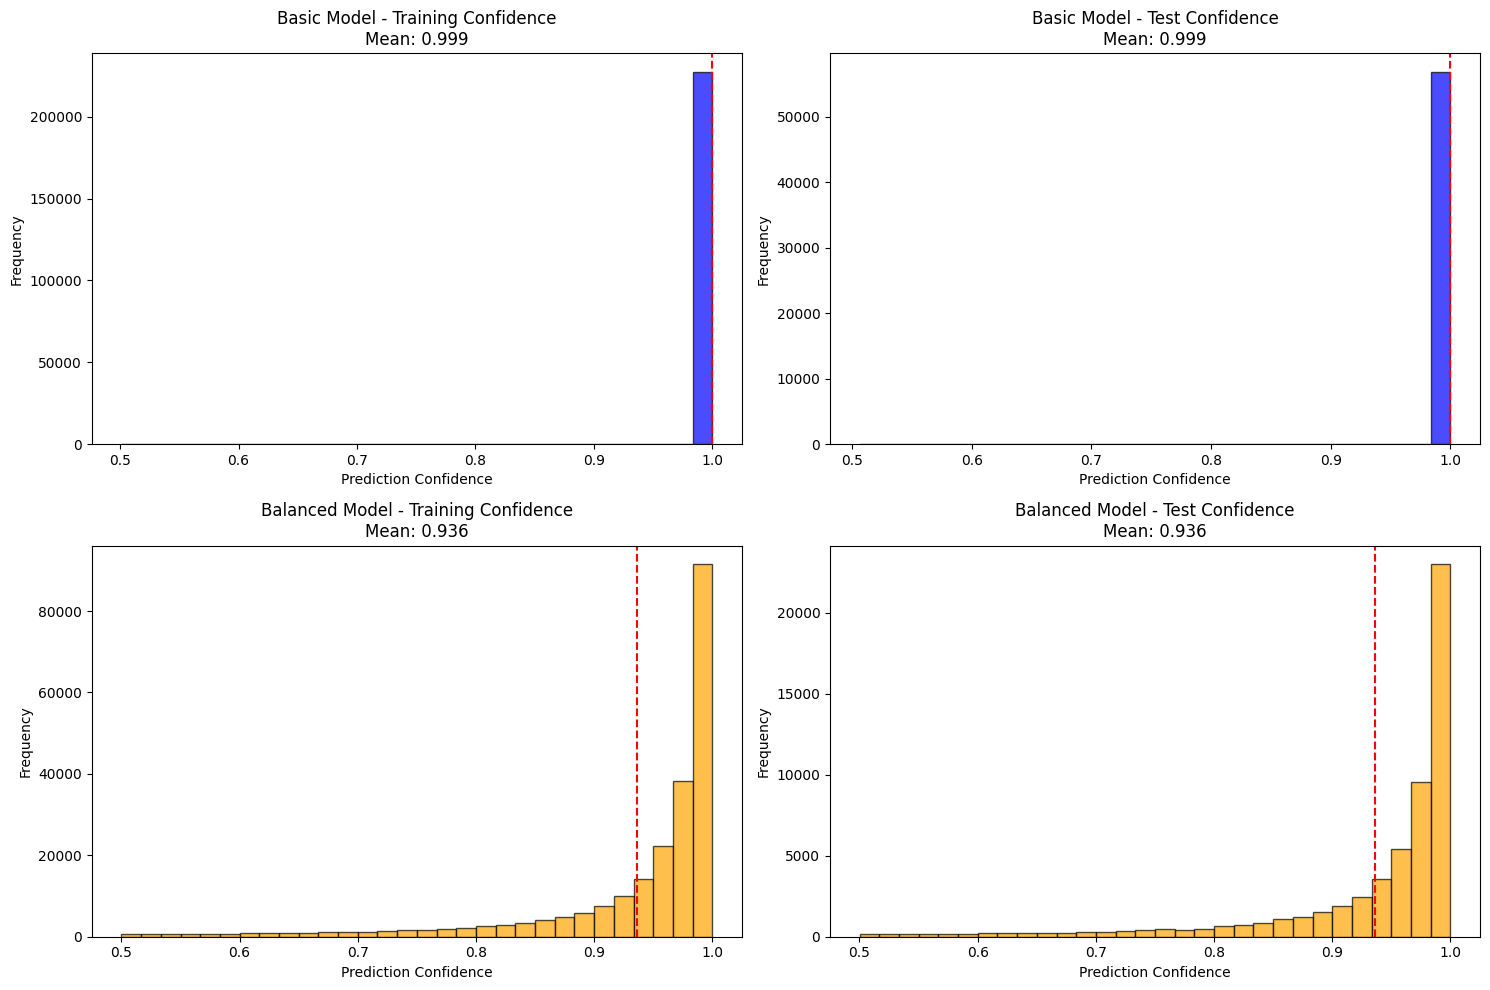

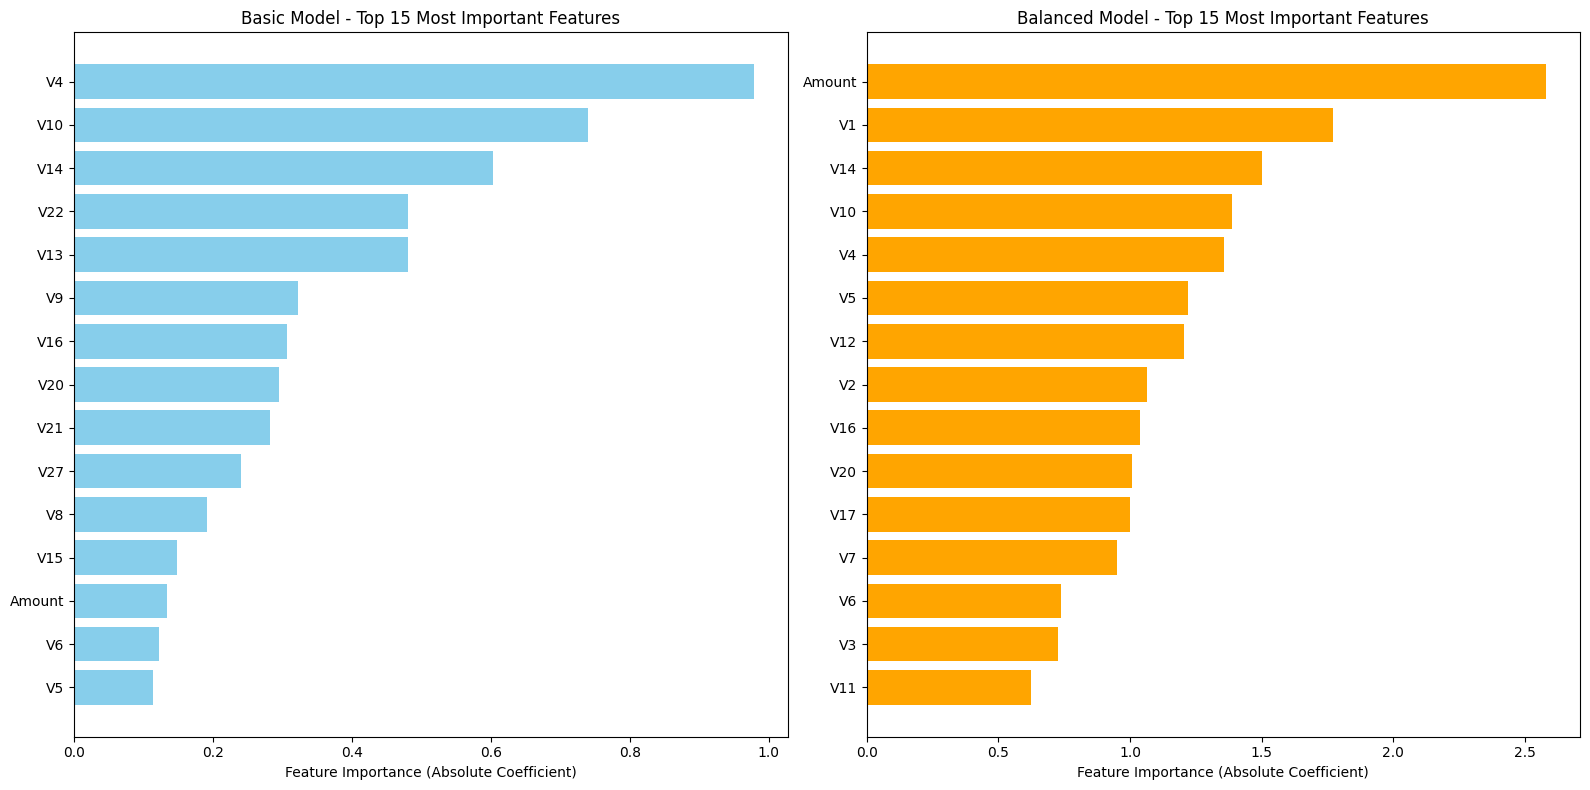

                 FINAL MODEL COMPARISON SUMMARY
Dataset: Credit Card Fraud Detection
Dataset Size: 284,807 transactions
Features: 29 (V1-V28 + Amount)
Class Imbalance Ratio: 577.9:1
Training Size: 227,845 | Test Size: 56,962

METRIC               BASIC           BALANCED       
Test Accuracy        0.999           0.974          
Test Precision       0.829           0.059          
Test Recall          0.643           0.918          
Test F1-Score        0.724           0.110          
Test AUC-ROC         0.958           0.971          
Test Error Rate      0.001           0.026          

=== KEY INSIGHTS FOR IMBALANCED DATA ===
🔍 Class Distribution: 492 frauds out of 284,807 transactions
📊 Basic Model: High accuracy (0.999) but poor fraud detection (Recall: 0.643)
⚖️  Balanced Model: Lower accuracy (0.974) but better fraud detection (Recall: 0.918)
🎯 For fraud detection, Balanced Model is preferred due to higher recall
💡 F1-Score comparison: Basic=0.724 vs Balanced=0.110

=== COMPAR

In [3]:
# Cell 2: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                           precision_recall_curve, roc_auc_score, roc_curve,
                           precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

# Cell 3: Load and Explore the Dataset
# Load the credit card fraud dataset
df = pd.read_csv('creditcard.csv')

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Check class distribution (imbalance)
print("\n=== CLASS DISTRIBUTION ===")
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nClass Distribution Percentages:")
print(f"Normal (0): {class_counts[0]/len(df)*100:.2f}%")
print(f"Fraud (1): {class_counts[1]/len(df)*100:.2f}%")
print(f"Imbalance Ratio: {class_counts[0]/class_counts[1]:.1f}:1")

# Cell 4: Data Preprocessing and Feature Selection
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# The dataset has features V1-V28 (PCA transformed), Time, Amount, and Class
# We'll use all V1-V28 features plus Amount (excluding Time as it's not predictive)
feature_columns = [col for col in df.columns if col.startswith('V')] + ['Amount']
target_column = 'Class'

print(f"\nSelected Features ({len(feature_columns)}):")
print("V1-V28 (PCA transformed features) + Amount")
print(f"Target: {target_column}")

# Prepare feature matrix X and target vector y
X = df[feature_columns].copy()
y = df[target_column].copy()

print(f"\nFinal dataset shape: X={X.shape}, y={len(y)}")
print(f"Features: {X.columns.tolist()[:5]}...{X.columns.tolist()[-2:]}")

# Cell 5: Data Distribution Analysis
# Visualize class imbalance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'orange'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal', 'Fraud'], rotation=0)

# Class distribution pie chart
axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'], autopct='%1.2f%%',
           colors=['skyblue', 'orange'])
axes[1].set_title('Class Distribution (Percentage)')

# Amount distribution by class
df_sample = df.sample(n=min(10000, len(df)), random_state=42)  # Sample for visualization
axes[2].hist([df_sample[df_sample['Class']==0]['Amount'],
              df_sample[df_sample['Class']==1]['Amount']],
             bins=50, alpha=0.7, label=['Normal', 'Fraud'], color=['skyblue', 'orange'])
axes[2].set_xlabel('Transaction Amount')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Transaction Amount Distribution by Class')
axes[2].legend()
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# Cell 6: Split Data and Scale Features
# Split the data - stratify to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features (especially important for Amount feature)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split completed:")
print(f"Training set: X={X_train_scaled.shape}, y={len(y_train)}")
print(f"Test set: X={X_test_scaled.shape}, y={len(y_test)}")

# Check class distribution in train/test sets
train_dist = y_train.value_counts()
test_dist = y_test.value_counts()
print(f"\nTraining set distribution:")
print(f"  Normal: {train_dist[0]} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f"  Fraud: {train_dist[1]} ({train_dist[1]/len(y_train)*100:.2f}%)")
print(f"\nTest set distribution:")
print(f"  Normal: {test_dist[0]} ({test_dist[0]/len(y_test)*100:.2f}%)")
print(f"  Fraud: {test_dist[1]} ({test_dist[1]/len(y_test)*100:.2f}%)")

# Cell 7: Train Logistic Regression Models
# Train basic logistic regression
print("Training Basic Logistic Regression...")
log_reg_basic = LogisticRegression(random_state=42, max_iter=1000)
log_reg_basic.fit(X_train_scaled, y_train)

# Train class-balanced logistic regression
print("Training Class-Balanced Logistic Regression...")
log_reg_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)

# Make predictions for both models
print("Making predictions...")

# Basic model predictions
y_train_pred_basic = log_reg_basic.predict(X_train_scaled)
y_test_pred_basic = log_reg_basic.predict(X_test_scaled)
y_train_prob_basic = log_reg_basic.predict_proba(X_train_scaled)[:, 1]
y_test_prob_basic = log_reg_basic.predict_proba(X_test_scaled)[:, 1]

# Balanced model predictions
y_train_pred_balanced = log_reg_balanced.predict(X_train_scaled)
y_test_pred_balanced = log_reg_balanced.predict(X_test_scaled)
y_train_prob_balanced = log_reg_balanced.predict_proba(X_train_scaled)[:, 1]
y_test_prob_balanced = log_reg_balanced.predict_proba(X_test_scaled)[:, 1]

print("Models trained successfully!")

# Cell 8: Model Evaluation - Accuracy and Classification Metrics
def evaluate_model(y_true, y_pred, y_prob, model_name, dataset_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob)

    print(f"\n=== {model_name} - {dataset_name} ===")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")

    return accuracy, precision, recall, f1, auc_roc

print("="*60)
print("                 MODEL PERFORMANCE COMPARISON")
print("="*60)

# Evaluate Basic Model
basic_train_metrics = evaluate_model(y_train, y_train_pred_basic, y_train_prob_basic,
                                   "Basic Logistic Regression", "Training Set")
basic_test_metrics = evaluate_model(y_test, y_test_pred_basic, y_test_prob_basic,
                                  "Basic Logistic Regression", "Test Set")

# Evaluate Balanced Model
balanced_train_metrics = evaluate_model(y_train, y_train_pred_balanced, y_train_prob_balanced,
                                      "Balanced Logistic Regression", "Training Set")
balanced_test_metrics = evaluate_model(y_test, y_test_pred_balanced, y_test_prob_balanced,
                                     "Balanced Logistic Regression", "Test Set")

# Calculate error rates
basic_train_error = 1 - basic_train_metrics[0]
basic_test_error = 1 - basic_test_metrics[0]
balanced_train_error = 1 - balanced_train_metrics[0]
balanced_test_error = 1 - balanced_test_metrics[0]

print(f"\n=== ERROR RATES ===")
print(f"Basic Model - Training Error: {basic_train_error:.4f} ({basic_train_error*100:.2f}%)")
print(f"Basic Model - Test Error: {basic_test_error:.4f} ({basic_test_error*100:.2f}%)")
print(f"Balanced Model - Training Error: {balanced_train_error:.4f} ({balanced_train_error*100:.2f}%)")
print(f"Balanced Model - Test Error: {balanced_test_error:.4f} ({balanced_test_error*100:.2f}%)")

# Cell 9: Confusion Matrix Visualization
# Create confusion matrices
train_cm_basic = confusion_matrix(y_train, y_train_pred_basic)
test_cm_basic = confusion_matrix(y_test, y_test_pred_basic)
train_cm_balanced = confusion_matrix(y_train, y_train_pred_balanced)
test_cm_balanced = confusion_matrix(y_test, y_test_pred_balanced)

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Basic model - Training
sns.heatmap(train_cm_basic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'], ax=axes[0,0])
axes[0,0].set_title(f'Basic Model - Training\nAccuracy: {basic_train_metrics[0]:.3f}')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# Basic model - Test
sns.heatmap(test_cm_basic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'], ax=axes[0,1])
axes[0,1].set_title(f'Basic Model - Test\nAccuracy: {basic_test_metrics[0]:.3f}')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# Balanced model - Training
sns.heatmap(train_cm_balanced, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'], ax=axes[1,0])
axes[1,0].set_title(f'Balanced Model - Training\nAccuracy: {balanced_train_metrics[0]:.3f}')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# Balanced model - Test
sns.heatmap(test_cm_balanced, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'], ax=axes[1,1])
axes[1,1].set_title(f'Balanced Model - Test\nAccuracy: {balanced_test_metrics[0]:.3f}')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Cell 10: ROC Curves and Precision-Recall Curves
# Plot ROC and PR curves
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ROC Curves
fpr_basic, tpr_basic, _ = roc_curve(y_test, y_test_prob_basic)
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_test_prob_balanced)

axes[0,0].plot(fpr_basic, tpr_basic, label=f'Basic Model (AUC = {basic_test_metrics[4]:.3f})', color='blue')
axes[0,0].plot(fpr_balanced, tpr_balanced, label=f'Balanced Model (AUC = {balanced_test_metrics[4]:.3f})', color='orange')
axes[0,0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curves - Test Set')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Precision-Recall Curves
precision_basic, recall_basic, _ = precision_recall_curve(y_test, y_test_prob_basic)
precision_balanced, recall_balanced, _ = precision_recall_curve(y_test, y_test_prob_balanced)

axes[0,1].plot(recall_basic, precision_basic, label=f'Basic Model', color='blue')
axes[0,1].plot(recall_balanced, precision_balanced, label=f'Balanced Model', color='orange')
axes[0,1].axhline(y=y_test.sum()/len(y_test), color='k', linestyle='--', label='Random')
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall Curves - Test Set')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Prediction probability distributions
axes[1,0].hist([y_test_prob_basic[y_test==0], y_test_prob_basic[y_test==1]],
               bins=50, alpha=0.7, label=['Normal', 'Fraud'], color=['skyblue', 'red'])
axes[1,0].set_xlabel('Prediction Probability')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Basic Model - Probability Distribution')
axes[1,0].legend()
axes[1,0].set_yscale('log')

axes[1,1].hist([y_test_prob_balanced[y_test==0], y_test_prob_balanced[y_test==1]],
               bins=50, alpha=0.7, label=['Normal', 'Fraud'], color=['skyblue', 'red'])
axes[1,1].set_xlabel('Prediction Probability')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Balanced Model - Probability Distribution')
axes[1,1].legend()
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

# Cell 11: Comprehensive ROC Curve Analysis
# Calculate ROC curves for both training and test sets
from sklearn.metrics import auc

# Training set ROC curves
fpr_basic_train, tpr_basic_train, thresholds_basic_train = roc_curve(y_train, y_train_prob_basic)
fpr_balanced_train, tpr_balanced_train, thresholds_balanced_train = roc_curve(y_train, y_train_prob_balanced)
auc_basic_train = auc(fpr_basic_train, tpr_basic_train)
auc_balanced_train = auc(fpr_balanced_train, tpr_balanced_train)

# Test set ROC curves
fpr_basic_test, tpr_basic_test, thresholds_basic_test = roc_curve(y_test, y_test_prob_basic)
fpr_balanced_test, tpr_balanced_test, thresholds_balanced_test = roc_curve(y_test, y_test_prob_balanced)
auc_basic_test = auc(fpr_basic_test, tpr_basic_test)
auc_balanced_test = auc(fpr_balanced_test, tpr_balanced_test)

# Create comprehensive ROC analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training ROC Curves
axes[0,0].plot(fpr_basic_train, tpr_basic_train, linewidth=2,
               label=f'Basic Model (AUC = {auc_basic_train:.3f})', color='blue')
axes[0,0].plot(fpr_balanced_train, tpr_balanced_train, linewidth=2,
               label=f'Balanced Model (AUC = {auc_balanced_train:.3f})', color='orange')
axes[0,0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0,0].set_xlim([0.0, 1.0])
axes[0,0].set_ylim([0.0, 1.05])
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].set_title('ROC Curves - Training Set')
axes[0,0].legend(loc="lower right")
axes[0,0].grid(True, alpha=0.3)

# Test ROC Curves
axes[0,1].plot(fpr_basic_test, tpr_basic_test, linewidth=2,
               label=f'Basic Model (AUC = {auc_basic_test:.3f})', color='blue')
axes[0,1].plot(fpr_balanced_test, tpr_balanced_test, linewidth=2,
               label=f'Balanced Model (AUC = {auc_balanced_test:.3f})', color='orange')
axes[0,1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curves - Test Set')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)

# ROC Curve Comparison (Both models on same plot)
axes[1,0].plot(fpr_basic_test, tpr_basic_test, linewidth=3,
               label=f'Basic Model (AUC = {auc_basic_test:.3f})', color='blue', alpha=0.8)
axes[1,0].plot(fpr_balanced_test, tpr_balanced_test, linewidth=3,
               label=f'Balanced Model (AUC = {auc_balanced_test:.3f})', color='orange', alpha=0.8)
axes[1,0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
axes[1,0].fill_between(fpr_basic_test, tpr_basic_test, alpha=0.2, color='blue')
axes[1,0].fill_between(fpr_balanced_test, tpr_balanced_test, alpha=0.2, color='orange')
axes[1,0].set_xlim([0.0, 1.0])
axes[1,0].set_ylim([0.0, 1.05])
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curve Comparison - Test Set\n(with Area Under Curve)')
axes[1,0].legend(loc="lower right")
axes[1,0].grid(True, alpha=0.3)

# Zoomed ROC (Focus on low FPR region)
axes[1,1].plot(fpr_basic_test, tpr_basic_test, linewidth=2,
               label=f'Basic Model (AUC = {auc_basic_test:.3f})', color='blue')
axes[1,1].plot(fpr_balanced_test, tpr_balanced_test, linewidth=2,
               label=f'Balanced Model (AUC = {auc_balanced_test:.3f})', color='orange')
axes[1,1].plot([0, 0.2], [0, 0.2], 'k--', linewidth=1, label='Random Classifier')
axes[1,1].set_xlim([0.0, 0.2])  # Zoom into low FPR region
axes[1,1].set_ylim([0.0, 1.0])
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curves (Zoomed) - Low FPR Region')
axes[1,1].legend(loc="lower right")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print ROC analysis summary
print("="*60)
print("                ROC CURVE ANALYSIS")
print("="*60)
print(f"Training Set AUC Scores:")
print(f"  Basic Model:    {auc_basic_train:.4f}")
print(f"  Balanced Model: {auc_balanced_train:.4f}")
print(f"\nTest Set AUC Scores:")
print(f"  Basic Model:    {auc_basic_test:.4f}")
print(f"  Balanced Model: {auc_balanced_test:.4f}")

# Calculate optimal thresholds using Youden's J statistic
j_basic = tpr_basic_test - fpr_basic_test
j_balanced = tpr_balanced_test - fpr_balanced_test
optimal_idx_basic = np.argmax(j_basic)
optimal_idx_balanced = np.argmax(j_balanced)

optimal_threshold_basic = thresholds_basic_test[optimal_idx_basic]
optimal_threshold_balanced = thresholds_balanced_test[optimal_idx_balanced]

print(f"\nOptimal Thresholds (Youden's J statistic):")
print(f"  Basic Model:    {optimal_threshold_basic:.4f}")
print(f"  Balanced Model: {optimal_threshold_balanced:.4f}")
print(f"\nAt Optimal Thresholds:")
print(f"  Basic Model - TPR: {tpr_basic_test[optimal_idx_basic]:.3f}, FPR: {fpr_basic_test[optimal_idx_basic]:.3f}")
print(f"  Balanced Model - TPR: {tpr_balanced_test[optimal_idx_balanced]:.3f}, FPR: {fpr_balanced_test[optimal_idx_balanced]:.3f}")

# Additional ROC metrics
print(f"\nROC Curve Insights:")
if auc_balanced_test > auc_basic_test:
    print(f"✅ Balanced Model has better AUC ({auc_balanced_test:.3f} vs {auc_basic_test:.3f})")
else:
    print(f"✅ Basic Model has better AUC ({auc_basic_test:.3f} vs {auc_balanced_test:.3f})")

print(f"📊 AUC Interpretation:")
print(f"   0.5 = Random classifier")
print(f"   0.5-0.7 = Poor performance")
print(f"   0.7-0.8 = Fair performance")
print(f"   0.8-0.9 = Good performance")
print(f"   0.9-1.0 = Excellent performance")

# Cell 12: Noise Analysis and Feature Importance
# Analyze prediction confidence and uncertainty
print("=== PREDICTION CONFIDENCE ANALYSIS ===")

# Basic Model
basic_train_confidence = np.maximum(y_train_prob_basic, 1 - y_train_prob_basic)
basic_test_confidence = np.maximum(y_test_prob_basic, 1 - y_test_prob_basic)

# Balanced Model
balanced_train_confidence = np.maximum(y_train_prob_balanced, 1 - y_train_prob_balanced)
balanced_test_confidence = np.maximum(y_test_prob_balanced, 1 - y_test_prob_balanced)

print(f"Basic Model:")
print(f"  Training - Mean confidence: {basic_train_confidence.mean():.3f}")
print(f"  Training - Std confidence: {basic_train_confidence.std():.3f}")
print(f"  Test - Mean confidence: {basic_test_confidence.mean():.3f}")
print(f"  Test - Std confidence: {basic_test_confidence.std():.3f}")

print(f"\nBalanced Model:")
print(f"  Training - Mean confidence: {balanced_train_confidence.mean():.3f}")
print(f"  Training - Std confidence: {balanced_train_confidence.std():.3f}")
print(f"  Test - Mean confidence: {balanced_test_confidence.mean():.3f}")
print(f"  Test - Std confidence: {balanced_test_confidence.std():.3f}")

# Plot confidence distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Basic model confidence
axes[0,0].hist(basic_train_confidence, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_xlabel('Prediction Confidence')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title(f'Basic Model - Training Confidence\nMean: {basic_train_confidence.mean():.3f}')
axes[0,0].axvline(basic_train_confidence.mean(), color='red', linestyle='--')

axes[0,1].hist(basic_test_confidence, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0,1].set_xlabel('Prediction Confidence')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title(f'Basic Model - Test Confidence\nMean: {basic_test_confidence.mean():.3f}')
axes[0,1].axvline(basic_test_confidence.mean(), color='red', linestyle='--')

# Balanced model confidence
axes[1,0].hist(balanced_train_confidence, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1,0].set_xlabel('Prediction Confidence')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title(f'Balanced Model - Training Confidence\nMean: {balanced_train_confidence.mean():.3f}')
axes[1,0].axvline(balanced_train_confidence.mean(), color='red', linestyle='--')

axes[1,1].hist(balanced_test_confidence, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1,1].set_xlabel('Prediction Confidence')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title(f'Balanced Model - Test Confidence\nMean: {balanced_test_confidence.mean():.3f}')
axes[1,1].axvline(balanced_test_confidence.mean(), color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Feature importance analysis
basic_feature_importance = np.abs(log_reg_basic.coef_[0])
balanced_feature_importance = np.abs(log_reg_balanced.coef_[0])

# Get top 15 most important features
top_n = 15
top_features_idx_basic = np.argsort(basic_feature_importance)[-top_n:]
top_features_idx_balanced = np.argsort(balanced_feature_importance)[-top_n:]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Basic model feature importance
axes[0].barh(range(top_n), basic_feature_importance[top_features_idx_basic], color='skyblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([feature_columns[i] for i in top_features_idx_basic])
axes[0].set_xlabel('Feature Importance (Absolute Coefficient)')
axes[0].set_title('Basic Model - Top 15 Most Important Features')

# Balanced model feature importance
axes[1].barh(range(top_n), balanced_feature_importance[top_features_idx_balanced], color='orange')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feature_columns[i] for i in top_features_idx_balanced])
axes[1].set_xlabel('Feature Importance (Absolute Coefficient)')
axes[1].set_title('Balanced Model - Top 15 Most Important Features')

plt.tight_layout()
plt.show()

# Cell 13: Final Comparison and Summary
print("="*80)
print("                 FINAL MODEL COMPARISON SUMMARY")
print("="*80)
print(f"Dataset: Credit Card Fraud Detection")
print(f"Dataset Size: {len(df):,} transactions")
print(f"Features: {len(feature_columns)} (V1-V28 + Amount)")
print(f"Class Imbalance Ratio: {class_counts[0]/class_counts[1]:.1f}:1")
print(f"Training Size: {len(X_train_scaled):,} | Test Size: {len(X_test_scaled):,}")

print(f"\n{'='*40}")
print(f"{'METRIC':<20} {'BASIC':<15} {'BALANCED':<15}")
print(f"{'='*40}")
print(f"{'Test Accuracy':<20} {basic_test_metrics[0]:<15.3f} {balanced_test_metrics[0]:<15.3f}")
print(f"{'Test Precision':<20} {basic_test_metrics[1]:<15.3f} {balanced_test_metrics[1]:<15.3f}")
print(f"{'Test Recall':<20} {basic_test_metrics[2]:<15.3f} {balanced_test_metrics[2]:<15.3f}")
print(f"{'Test F1-Score':<20} {basic_test_metrics[3]:<15.3f} {balanced_test_metrics[3]:<15.3f}")
print(f"{'Test AUC-ROC':<20} {basic_test_metrics[4]:<15.3f} {balanced_test_metrics[4]:<15.3f}")
print(f"{'Test Error Rate':<20} {basic_test_error:<15.3f} {balanced_test_error:<15.3f}")

print(f"\n=== KEY INSIGHTS FOR IMBALANCED DATA ===")
print(f"🔍 Class Distribution: {class_counts[1]:,} frauds out of {len(df):,} transactions")
print(f"📊 Basic Model: High accuracy ({basic_test_metrics[0]:.3f}) but poor fraud detection (Recall: {basic_test_metrics[2]:.3f})")
print(f"⚖️  Balanced Model: Lower accuracy ({balanced_test_metrics[0]:.3f}) but better fraud detection (Recall: {balanced_test_metrics[2]:.3f})")
print(f"🎯 For fraud detection, Balanced Model is preferred due to higher recall")
print(f"💡 F1-Score comparison: Basic={basic_test_metrics[3]:.3f} vs Balanced={balanced_test_metrics[3]:.3f}")

# Compare with previous energy model (conceptually)
print(f"\n=== COMPARISON WITH ENERGY MODEL (Conceptual) ===")
print(f"🌍 Energy Model: Multi-class classification (3 classes), balanced dataset")
print(f"💳 Fraud Model: Binary classification (2 classes), highly imbalanced dataset")
print(f"📈 Key Difference: Imbalanced data requires different evaluation metrics")
print(f"🔧 Solution: Class weighting, different thresholds, focus on Precision/Recall")

fraud_detected = (y_test_pred_balanced == 1).sum()
actual_frauds = (y_test == 1).sum()
print(f"\n🚨 Fraud Detection Results (Balanced Model):")
print(f"   Actual frauds in test set: {actual_frauds}")
print(f"   Frauds detected by model: {fraud_detected}")
print(f"   True frauds caught: {((y_test_pred_balanced == 1) & (y_test == 1)).sum()}")

print("\n" + "="*80)